FRAMEWORK TO CONVERT A GENERAL CNN TO A NETWORK CONTAINING ONLY FULLY CONNECTED LAYERS

At the current state the original network has to have only layer which contain (InputLayer, FC, Conv2d, MaxPool2d, BatchNormalization, Flatten) layers. As example, it will used a network having a batch size of 32 and with the structure:
 INPUT (40, 40, 1) -> BATCH NORMALIZATION -> CONV2D -> MAXPOOL2D -> CONV2D -> MAXPOOL2D -> CONV2D -> CONV2D -> FC -> FC (classification with softmax activation)

The network above will be converted into an equal one with the following structure:

|   Original Layer  |   Output Shape |   FC Neurons  |   Method   |
-------------------------------------------------------------------
|   1. Input        |   (40,40,1)    |       -       |   Flatten  |
|   2. BN + Conv2D  |   (40,40,8)    |     12800     | Direct FC  |
|   3. MaxPool2D    |   (13,13,8)    |      6400     |  Distill   |
|   4. Conv2D       |   (13,13,16)   |      2704     | Direct FC  |
|   5. MaxPool2D    |   (6,6,16)     |      1352     |  Distill   |
|   6. Conv2D       |   (3,3,32)     |      288      | Direct FC  |
|   7. Conv2D       |   (2,2,64)     |      256      | Direct FC  |
|   8. Flatten      |   (256)        |      256      |  Flatten   |
|   9. FC           |   (128)        |      128      | Already FC |
|   10. FC (output) |   (94)         |      94       | Already FC |
-------------------------------------------------------------------

[1] Train, test and validation data split and uploading of the teacher model. Threshold parameter passed in create_dataset function is at most 1448 for the dataset provided and it indicates that for each class there will be 1448 samples, this is done to have a balanced dataset per class

In [ ]:
import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, layers
from sklearn.model_selection import train_test_split

#1. Set random seed
seed=22
tf.random.set_seed(seed)
np.random.seed(seed)

def create_dataset(shape_input, file, values_name, labels_name, threshold, percentage=1.0):
    if len(shape_input)==3:
        height, width, channels=shape_input
    elif len(shape_input)==2:
        height, width=shape_input
        channels=1
    else:
        raise ValueError("Shape Input must be (height, width) or (height, width, channels)")

    # Load dataset
    dataset = np.load(file)
    samples = dataset[values_name][:, :height, :width]
    classes = dataset[labels_name].astype(int)

    # Filter classes if threshold
    filtered_samples, filtered_classes = [], []
    unique_classes, counts = np.unique(classes, return_counts=True)
    keep_classes = unique_classes if threshold == -1 else unique_classes[counts >= threshold]
    
    for cls in keep_classes:
        cls_indices = np.where(classes == cls)[0]
        if threshold != -1:
            cls_indices = np.random.choice(cls_indices, size=threshold, replace=False)
        filtered_samples.append(samples[cls_indices])
        filtered_classes.append(classes[cls_indices])

    filtered_samples = np.concatenate(filtered_samples)
    filtered_classes = np.concatenate(filtered_classes)

    # Normalize class indices
    unique_classes = np.unique(filtered_classes)
    class_mapping = {cls: idx for idx, cls in enumerate(unique_classes)}
    filtered_classes = np.array([class_mapping[cls] for cls in filtered_classes])

    # Split into train/val/test
    X_train, X_temp, y_train, y_temp = train_test_split(
        filtered_samples, filtered_classes, test_size=0.3, random_state=seed, stratify=filtered_classes)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp)

    if percentage < 1.0:
        X_train_reduced, y_train_reduced = [], []
        for cls in np.unique(y_train):
            cls_indices = np.where(y_train == cls)[0]
            n_keep = int(len(cls_indices) * percentage)
            selected = np.random.choice(cls_indices, size=n_keep, replace=False)
            X_train_reduced.append(X_train[selected])
            y_train_reduced.append(y_train[selected])
        X_train = np.concatenate(X_train_reduced)
        y_train = np.concatenate(y_train_reduced)

    # Add channel dimension
    if len(shape_input) == 2:
        X_train = np.expand_dims(X_train, axis=-1)
        X_val   = np.expand_dims(X_val, axis=-1)
        X_test  = np.expand_dims(X_test, axis=-1)

    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    print(f"Number of classes: {len(unique_classes)}")

    return X_train, y_train, X_val, y_val, X_test, y_test, len(unique_classes)


# Splitting Dataset Generation
shape_input=(40,40,1)
X_train, y_train, X_val, y_val, X_test, y_test, n_classes = create_dataset(
   shape_input, file="sheila-mfe-1sec.npz", 
    values_name="features", labels_name="labels", threshold=-1, percentage=1.0)
#X_train, y_train, X_val, y_val, X_test, y_test, n_classes=create_dataset(
#    shape_input, file="librispeech-train-100-clean-mfe-1sec.npz",
#    values_name="features", labels_name="speaker_labels", threshold=1448
#)
print("\n" + "="*50)
print("FIXING DATASET SHAPE FOR MODEL COMPATIBILITY")
print("="*50)

print("Before reshaping:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

# Add the channel dimension explicitly
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("\nAfter reshaping:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val: {X_val.shape}")
print(f"  X_test: {X_test.shape}")

print(f"NUM CLASSES: {n_classes}")
# 6. Load teacher model, that extracts only d-vector
#teacher_dvec_model = tf.keras.models.load_model("cnn-librispeech-classifier.h5")
teacher_dvec_model=tf.keras.models.load_model("kws_cnn_teacher.h5")
teacher_dvec_model.summary()

Train: (1300, 40, 40), Val: (2787, 40, 40), Test: (2787, 40, 40)
Number of classes: 2

FIXING DATASET SHAPE FOR MODEL COMPATIBILITY
Before reshaping:
  X_train: (1300, 40, 40)
  X_val: (2787, 40, 40)
  X_test: (2787, 40, 40)

After reshaping:
  X_train: (1300, 40, 40, 1)
  X_val: (2787, 40, 40, 1)
  X_test: (2787, 40, 40, 1)
NUM CLASSES: 2


Model: "teacher_kws_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 40, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 40, 40, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_99          │ (None, 40, 40, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_99 (ReLU)                 │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_114 (Dropout)           │ (None, 20, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 20, 20, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_100         │ (None, 20, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_100 (ReLU)                │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_115 (Dropout)           │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 10, 10, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_101         │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_101 (ReLU)                │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_116 (Dropout)           │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 256)            │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_102         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_102 (ReLU)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_117 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (None, 128)            │           51

 Total params: 955,428 (3.64 MB)

 Trainable params: 954,082 (3.64 MB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 2 (12.00 B)

In [37]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))
print("Class distribution:", class_distribution)

# Calculate imbalance ratio
imbalance_ratio = max(counts) / min(counts)
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:", class_weight_dict)

Class distribution: {0: 1138, 1: 162}
Imbalance ratio: 7.02:1
Class weights: {0: 0.5711775043936731, 1: 4.012345679012346}


Phase 1 - Feature Extraction from the penultimate layer

In [38]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
from typing import Dict, Tuple

def get_layer_by_index(model, layer_index=-2):
    if abs(layer_index)>=len(model.layers):
        raise IndexError(f"Layer index {layer_index} is out of range. Model has {len(model.layers)} layers.")
    return model.layers[layer_index]

def build_feature_extractor_by_index(model, layer_index=-2):
    layer=get_layer_by_index(model, layer_index)
    print(f"Using layer {layer_index}: '{layer.name}' ({layer.__class__.__name__})")
    return tf.keras.Model(inputs=model.input, outputs=layer.output)

def extract_features(model, dataset, layer_index=-2, flatten=True, verbose=True):
    extractor_model=build_feature_extractor_by_index(model, layer_index)
    all_features=[]
    all_labels=[]
    iterator=tqdm(dataset, desc=f"Extracting from layer {layer_index}") if verbose else dataset
    
    for x_batch, y_batch in iterator:
        features=extractor_model(x_batch, training=False)
        if len(features.shape)>2:
            features=tf.reduce_mean(features, axis=[1,2])
        if flatten:
            features=tf.reshape(features, [features.shape[0], -1])
        all_features.append(features.numpy())
        all_labels.append(y_batch.numpy())
    X=np.concatenate(all_features, axis=0)
    y=np.concatenate(all_labels, axis=0)
    return X, y

def extract_from_splits(model, datasets, layer_index=-2, flatten=True, save_path=None):
    results={}
    for split_name, ds in datasets.items():
        X, y=extract_features(model, ds, layer_index, flatten=flatten)
        results[split_name]=(X, y)
        if save_path is not None:
            np.savez(f"{save_path}_{split_name}.npz", X=X, y=y)
    return results

batch_size=32
train_ds=tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds=tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds=tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

datasets={
    "train": train_ds,
    "test": test_ds,
    "val": val_ds
}

features=extract_from_splits(model=teacher_dvec_model, datasets=datasets, layer_index=-2, save_path="teacher_features")

X_train_features, y_train_features=features["train"]
X_val_features, y_val_features=features["val"]
X_test_features, y_test_features=features["test"]

print(f"Train features: {X_train_features.shape}")
print(f"Validation features: {X_val_features.shape}")
print(f"Test Features: {X_test_features.shape}")

Using layer -2: 'dropout_119' (Dropout)


Extracting from layer -2: 100%|██████████| 41/41 [00:01<00:00, 24.94it/s]


Using layer -2: 'dropout_119' (Dropout)


Extracting from layer -2: 100%|██████████| 88/88 [00:01<00:00, 53.00it/s]


Using layer -2: 'dropout_119' (Dropout)


Extracting from layer -2: 100%|██████████| 88/88 [00:01<00:00, 61.29it/s]

Train features: (1300, 64)
Validation features: (2787, 64)
Test Features: (2787, 64)


Phase 2 - Intermediate Dense Model
Input = extracted teacher features from penultimate layer
Output = classification

In [39]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

print("=== PHASE 2: Dense Field Creation with Class Balancing ===")

# --- Hyperparameters ---
input_dim = X_train_features.shape[1]  # dimension of teacher features
embedding_dim = X_train_features.shape[1]   # dense latent space
dropout_rate = 0.2
batch_size = 32
epochs = 25
lambda_cls = 0.1                        # label-aware loss weight

# --- NORMALIZE Input Features (Critical!) ---
def normalize_features(features, mean=None, std=None):
    """Normalize features to zero mean and unit variance"""
    if mean is None or std is None:
        mean = np.mean(features, axis=0)
        std = np.std(features, axis=0) + 1e-8  # Avoid division by zero
    return (features - mean) / std, mean, std

# Normalize all features
X_train_features_norm, train_mean, train_std = normalize_features(X_train_features)
X_val_features_norm = (X_val_features - train_mean) / train_std
X_test_features_norm = (X_test_features - train_mean) / train_std

print(f"Original features range: {X_train_features.min():.2f} to {X_train_features.max():.2f}")
print(f"Normalized features range: {X_train_features_norm.min():.2f} to {X_train_features_norm.max():.2f}")

# --- Calculate Class Weights for Imbalance ---
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_features), y=y_train_features)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights for imbalance: {class_weight_dict}")

# --- Build Autoencoder ---
def build_autoencoder(input_dim, embedding_dim, dropout_rate=0.2, num_classes=2):
    """Build autoencoder with classification head"""
    inputs = layers.Input(shape=(input_dim,))
    
    # Encoder
    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    
    # Latent space (use linear activation for better representation)
    z = layers.Dense(embedding_dim, activation='linear', name='latent')(x)
    
    # Decoder
    x_dec = layers.Dense(256, activation='relu')(z)
    x_dec = layers.Dropout(dropout_rate)(x_dec)
    x_dec = layers.Dense(512, activation='relu')(x_dec)
    x_dec = layers.Dropout(dropout_rate)(x_dec)
    outputs = layers.Dense(input_dim, activation='linear', name='reconstruction')(x_dec)
    
    # Classification head
    y_pred = layers.Dense(num_classes, activation='softmax', name='label_pred')(z)
    
    model = models.Model(inputs=inputs, outputs=[outputs, y_pred])
    return model

# --- Custom Weighted Loss Function for Imbalance ---
def weighted_sparse_crossentropy(class_weights):
    """Custom loss function that handles class imbalance"""
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    
    def loss_fn(y_true, y_pred):
        # Convert sparse labels to one-hot to calculate weights
        y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=len(class_weights))
        weights = tf.reduce_sum(y_true_onehot * class_weights_tensor, axis=1)
        
        # Calculate sparse categorical crossentropy
        ce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        
        # Apply class weights
        weighted_ce = ce * weights
        return tf.reduce_mean(weighted_ce)
    
    return loss_fn

# --- Instantiate and compile autoencoder ---
autoencoder = build_autoencoder(
    input_dim=input_dim, 
    embedding_dim=embedding_dim,
    dropout_rate=dropout_rate, 
    num_classes=2
)

# Define losses with custom weighted loss for classification
losses_dict = {
    'reconstruction': losses.MeanSquaredError(),
    'label_pred': weighted_sparse_crossentropy(class_weights)  # Custom weighted loss
}

loss_weights = {'reconstruction': 1.0, 'label_pred': lambda_cls}

autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=losses_dict,
    loss_weights=loss_weights,
    metrics={'label_pred': ['accuracy']}
)

autoencoder.summary()


callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        min_delta=0.001
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_encoder_model.h5',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
]

# --- Train autoencoder ---
print("Training autoencoder with class balancing...")
history = autoencoder.fit(
    X_train_features_norm,  # Normalized inputs
    {
        'reconstruction': X_train_features_norm, 
        'label_pred': y_train_features  # Original labels (0, 1)
    },
    validation_data=(
        X_val_features_norm, 
        {
            'reconstruction': X_val_features_norm, 
            'label_pred': y_val_features
        }
    ),
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks
)

# --- Extract encoder and create dense embeddings ---
encoder_model = tf.keras.Model(
    inputs=autoencoder.input, 
    outputs=autoencoder.get_layer('latent').output
)

print("Creating dense embeddings...")
Z_train_features = encoder_model.predict(X_train_features_norm, batch_size=batch_size)
Z_val_features = encoder_model.predict(X_val_features_norm, batch_size=batch_size)
Z_test_features = encoder_model.predict(X_test_features_norm, batch_size=batch_size)

# --- NORMALIZE Embeddings (Critical for Phase 3) ---
def normalize_embeddings(embeddings, mean=None, std=None):
    """Normalize embeddings to zero mean and unit variance"""
    if mean is None or std is None:
        mean = np.mean(embeddings, axis=0)
        std = np.std(embeddings, axis=0) + 1e-8
    return (embeddings - mean) / std, mean, std

Z_train_features, emb_mean, emb_std = normalize_embeddings(Z_train_features)
Z_val_features = (Z_val_features - emb_mean) / emb_std
Z_test_features = (Z_test_features - emb_mean) / emb_std

print(f"\n=== EMBEDDING STATISTICS ===")
print(f"Train embeddings shape: {Z_train_features.shape}")
print(f"Embeddings range: {Z_train_features.min():.3f} to {Z_train_features.max():.3f}")
print(f"Embeddings mean: {Z_train_features.mean():.3f}, std: {Z_train_features.std():.3f}")
print(f"Validation embeddings shape: {Z_val_features.shape}")
print(f"Test embeddings shape: {Z_test_features.shape}")

# --- Save embeddings for next phases ---
np.savez('dense_embeddings.npz', 
         Z_train=Z_train_features, 
         Z_val=Z_val_features, 
         Z_test=Z_test_features,
         emb_mean=emb_mean,
         emb_std=emb_std)

print("Phase 2 completed successfully! ✅")

=== PHASE 2: Dense Field Creation with Class Balancing ===
Original features range: 0.00 to 4.63
Normalized features range: -1.44 to 4.81
Class weights for imbalance: {0: 0.5711775043936731, 1: 4.012345679012346}


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 512)       │     33,280 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 512)       │          0 │ dense_16[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 256)       │    131,328 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 256)       │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Dense)      │ (None, 64)        │     16,448 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │     16,640 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 256)       │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 512)       │    131,584 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 512)       │          0 │ dense_19[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 64)        │     32,832 │ dropout_19[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_pred (Dense)  │ (None, 2)         │        130 │ latent[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 362,242 (1.38 MB)

 Trainable params: 362,242 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

Training autoencoder with class balancing...
Epoch 1/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - label_pred_accuracy: 0.8826 - label_pred_loss: 0.3291 - loss: 0.7995 - reconstruction_loss: 0.7666

41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - label_pred_accuracy: 0.9546 - label_pred_loss: 0.1302 - loss: 0.5795 - reconstruction_loss: 0.5661 - val_label_pred_accuracy: 0.9935 - val_label_pred_loss: 0.0468 - val_loss: 0.0667 - val_reconstruction_loss: 0.0620 - learning_rate: 0.0010
Epoch 2/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - label_pred_accuracy: 0.9754 - label_pred_loss: 0.0581 - loss: 0.4208 - reconstruction_loss: 0.4180 - val_label_pred_accuracy: 0.9943 - val_label_pred_loss: 0.0337 - val_loss: 0.0735 - val_reconstruction_loss: 0.0700 - learning_rate: 0.0010
Epoch 3/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - label_pred_accuracy: 0.9215 - label_pred_loss: 0.2478 - loss: 3.0133 - reconstruction_loss: 3.1186 - val_label_pred_accuracy: 0.9078 - val_label_pred_loss: 0.1669 - val_loss: 1.6022 - val_reconstruction_loss: 1.5841 - learning_rate: 0.0010
Epoch 4/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - label_pred_accuracy: 0.8277 - label_pred_loss: 5.3904 - loss: 192.1576 - recon

Step 3 - Inverted Network Training

In [40]:
import math
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import numpy as np
from sklearn.utils import class_weight

print("=== PHASE 3: Inverter Network Training ===")

# --- Load normalized embeddings from Phase 2 ---
embeddings_data = np.load('dense_embeddings.npz')
Z_train_features = embeddings_data['Z_train']
Z_val_features = embeddings_data['Z_val']
Z_test_features = embeddings_data['Z_test']

print(f"Loaded embeddings - Train: {Z_train_features.shape}, Val: {Z_val_features.shape}")

# --- Prepare flattened image data (NORMALIZED) ---
X_train_flat = X_train.reshape(len(X_train), -1).astype('float32') / 255.0
X_val_flat = X_val.reshape(len(X_val), -1).astype('float32') / 255.0
X_test_flat = X_test.reshape(len(X_test), -1).astype('float32') / 255.0

print(f"Flattened images - Train: {X_train_flat.shape}, Val: {X_val_flat.shape}")
print(f"Input range: {X_train_flat.min():.3f} to {X_train_flat.max():.3f}")

# --- Calculate sample weights for class imbalance ---
sample_weights = class_weight.compute_sample_weight('balanced', y_train)
print(f"Sample weights range: {sample_weights.min():.3f} to {sample_weights.max():.3f}")

# --- Build Inverter Model ---
def build_inverter_model(input_dim=1600, embedding_dim=64):
    """Builds model to predict teacher embeddings from flattened images"""
    inputs = layers.Input(shape=(input_dim,), name="input_layer")
    def nearest_lower_power(n):
        return 2**int(math.floor(math.log2(n)))
    neurons=256
    #neurons=embedding_dim*8
    #if neurons>input_dim:
    #    neurons=nearest_lower_power(input_dim)
    x=inputs
    num_layers=0
    while num_layers<3:
        num_layers+=1
        x=layers.Dense(neurons, use_bias=False, name=f"dense_{num_layers}")(x)
        x=layers.BatchNormalization(name=f"bn_{num_layers}")(x)
        x=layers.Activation(activation='relu', name=f"activation_{num_layers}")(x)
        x=layers.Dropout(dropout_rate, name=f"dropout_{num_layers}")(x)
        #if neurons>embedding_dim:
        #    neurons=neurons//2
    
    # Output: predicted embeddings (64 dimensions)
    outputs = layers.Dense(embedding_dim, activation='linear', name='predicted_embeddings')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# --- Instantiate and compile inverter ---
inverter_model = build_inverter_model(1600, X_train_features.shape[1])
inverter_model.summary()

# Compile with lower learning rate and gradient clipping
inverter_model.compile(
    optimizer=optimizers.Adam(
        learning_rate=0.0001,  # Low learning rate for stability
        clipnorm=1.0           # Gradient clipping to prevent explosions
    ),
    loss='mse',
    metrics=['mae']
)

# --- Callbacks for stable training ---
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_mae',
        patience=10,
        restore_best_weights=True,
        min_delta=0.001
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_mae',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_inverter_model.h5',
        monitor='val_mae',
        save_best_only=True,
        mode='min'
    )
]

# --- Train inverter with sample weighting ---
print("Training inverter to predict teacher embeddings from flattened images...")
inverter_history = inverter_model.fit(
    X_train_flat, 
    Z_train_features,  # Normalized embeddings from Phase 2
    validation_data=(X_val_flat, Z_val_features),
    batch_size=32,
    epochs=100,
    sample_weight=sample_weights,  # Class imbalance handling
    callbacks=callbacks,
    verbose=1
)

# --- Synthesize embedding targets using the trained inverter ---
print("Synthesizing embedding targets for student training...")
y_embeddings_train = inverter_model.predict(X_train_flat, verbose=1, batch_size=256)
y_embeddings_val = inverter_model.predict(X_val_flat, verbose=1, batch_size=256)
y_embeddings_test = inverter_model.predict(X_test_flat, verbose=1, batch_size=256)

print(f"Synthesized embeddings - Train: {y_embeddings_train.shape}, Val: {y_embeddings_val.shape}")

# --- Evaluate inverter performance ---
from scipy.spatial.distance import cosine

# Calculate cosine similarity between real and predicted embeddings
cosine_sims = []
for i in range(min(1000, len(Z_val_features))):
    cos_sim = 1 - cosine(Z_val_features[i], y_embeddings_val[i])
    cosine_sims.append(cos_sim)

print(f"Inverter performance - Average cosine similarity: {np.mean(cosine_sims):.4f}")
print(f"Inverter performance - MAE: {np.mean(np.abs(Z_val_features - y_embeddings_val)):.4f}")

# --- Prepare final multi-task dataset ---
# Convert class labels to categorical
y_train_categorical = tf.keras.utils.to_categorical(y_train, num_classes=n_classes)
y_val_categorical = tf.keras.utils.to_categorical(y_val, num_classes=n_classes)
y_test_categorical = tf.keras.utils.to_categorical(y_test, num_classes=n_classes)

# Create dataset dictionary
multi_task_data = {
    'train': {
        'input': X_train_flat,
        'class_target': y_train_categorical,
        'embedding_target': y_embeddings_train
    },
    'val': {
        'input': X_val_flat,
        'class_target': y_val_categorical,
        'embedding_target': y_embeddings_val
    },
    'test': {
        'input': X_test_flat,
        'class_target': y_test_categorical,
        'embedding_target': y_embeddings_test
    }
}

# --- Save synthesized dataset for Phase 4 ---
np.savez('multi_task_dataset.npz', 
         X_train_flat=X_train_flat,
         y_embeddings_train=y_embeddings_train,
         y_embeddings_val=y_embeddings_val,
         y_embeddings_test=y_embeddings_test,
         y_train_categorical=y_train_categorical,
         y_val_categorical=y_val_categorical,
         y_test_categorical=y_test_categorical)

print("Phase 3 completed successfully! ✅")
print("Multi-task dataset ready for student training in Phase 4")

=== PHASE 3: Inverter Network Training ===
Loaded embeddings - Train: (1300, 64), Val: (2787, 64)
Flattened images - Train: (1300, 1600), Val: (2787, 1600)
Input range: 0.000 to 0.004
Sample weights range: 0.571 to 4.012


Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predicted_embeddings (Dense)    │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 560,192 (2.14 MB)

 Trainable params: 558,656 (2.13 MB)

...

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.2198 - mae: 0.4095 - val_loss: 0.2262 - val_mae: 0.3418 - learning_rate: 5.0000e-05
Epoch 78/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.2169 - mae: 0.4070 - val_loss: 0.2370 - val_mae: 0.3497 - learning_rate: 5.0000e-05
Epoch 79/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.2182 - mae: 0.4048 - val_loss: 0.2298 - val_mae: 0.3437 - learning_rate: 5.0000e-05
Epoch 80/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2125 - mae: 0.4054

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.2104 - mae: 0.4008 - val_loss: 0.2265 - val_mae: 0.3414 - learning_rate: 5.0000e-05
Epoch 81/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.2111 - mae: 0.4010 - val_loss: 0.2310 - val_mae: 0.3452 - learning_rate: 5.0000e-05
Epoch 82/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.2093 - mae: 0.3985 - val_loss: 0.2308 - val_mae: 0.3469 - learning_rate: 5.0000e-05
Epoch 83/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.2059 - mae: 0.3962 - val_loss: 0.2253 - val_mae: 0.3437 - learning_rate: 5.0000e-05
Epoch 84/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.2015 - mae: 0.3940 - val_loss: 0.2530 - val_mae: 0.3635 - learning_rate: 5.0000e-05
Epoch 85/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.2001 - mae: 0.3929 - val_loss: 0.2337 - val_mae: 0.3458 - learning_rate: 5.0000e-05
Epoch 86/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2106 - mae: 0.3962

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.2030 - mae: 0.3926 - val_loss: 0.2261 - val_mae: 0.3405 - learning_rate: 5.0000e-05
Epoch 87/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.1963 - mae: 0.3891 - val_loss: 0.2455 - val_mae: 0.3562 - learning_rate: 5.0000e-05
Epoch 88/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.1960 - mae: 0.3875 - val_loss: 0.2273 - val_mae: 0.3412 - learning_rate: 5.0000e-05
Epoch 89/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.2049 - mae: 0.3942

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.1989 - mae: 0.3886 - val_loss: 0.2229 - val_mae: 0.3366 - learning_rate: 5.0000e-05
Epoch 90/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.1928 - mae: 0.3825 - val_loss: 0.2292 - val_mae: 0.3447 - learning_rate: 5.0000e-05
Epoch 91/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.1905 - mae: 0.3828 - val_loss: 0.2225 - val_mae: 0.3397 - learning_rate: 5.0000e-05
Epoch 92/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.1920 - mae: 0.3828 - val_loss: 0.2494 - val_mae: 0.3619 - learning_rate: 5.0000e-05
Epoch 93/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.1883 - mae: 0.3807 - val_loss: 0.2229 - val_mae: 0.3375 - learning_rate: 5.0000e-05
Epoch 94/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.1883 - mae: 0.3777 - val_loss: 0.2265 - val_mae: 0.3389 - learning_rate: 5.0000e-05
Epoch 95/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.2002 - mae: 0.3869

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.1915 - mae: 0.3804 - val_loss: 0.2171 - val_mae: 0.3337 - learning_rate: 5.0000e-05
Epoch 96/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.1828 - mae: 0.3745 - val_loss: 0.2387 - val_mae: 0.3505 - learning_rate: 5.0000e-05
Epoch 97/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.1834 - mae: 0.3729 - val_loss: 0.2260 - val_mae: 0.3404 - learning_rate: 5.0000e-05
Epoch 98/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.1828 - mae: 0.3741 - val_loss: 0.2169 - val_mae: 0.3338 - learning_rate: 5.0000e-05
Epoch 99/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.1812 - mae: 0.3716 - val_loss: 0.2235 - val_mae: 0.3415 - learning_rate: 5.0000e-05
Epoch 100/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.1805 - mae: 0.3723 - val_loss: 0.2283 - val_mae: 0.3397 - learning_rate: 5.0000e-05
Synthesizing embedding targets for student training...
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/s

Phase 4 - Multitask Student Training

=== PHASE 4: Multi-Task Student Training ===
Data converted to TensorFlow tensors


Model: "multi_task_student"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1600)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    409,600 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ bn_1[1][0]        │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,536 │ dropout_1[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 256)       │      1,024 │ dense_2[1][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256)       │          0 │ bn_2[1][0]        │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ activation_2[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,536 │ dropout_2[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 256)       │      1,024 │ dense_3[1][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256)       │          0 │ bn_3[1][0]        │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ activation_3[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 2)         │        514 │ dropout_3[1][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_output    │ (None, 64)        │     16,448 │ dropout_3[1][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 560,706 (2.14 MB)

 Trainable params: 559,170 (2.13 MB)

...

 Total params: 544,258 (2.08 MB)

 Trainable params: 542,722 (2.07 MB)

 Non-trainable params: 1,536 (6.00 KB)

Evaluating final deployable model...
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8988 - loss: 0.2568



=== FINAL RESULTS ===
Test Accuracy: 0.8988
Test Loss: 0.2568
Final model saved as 'final_deployable_student_model.h5'
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


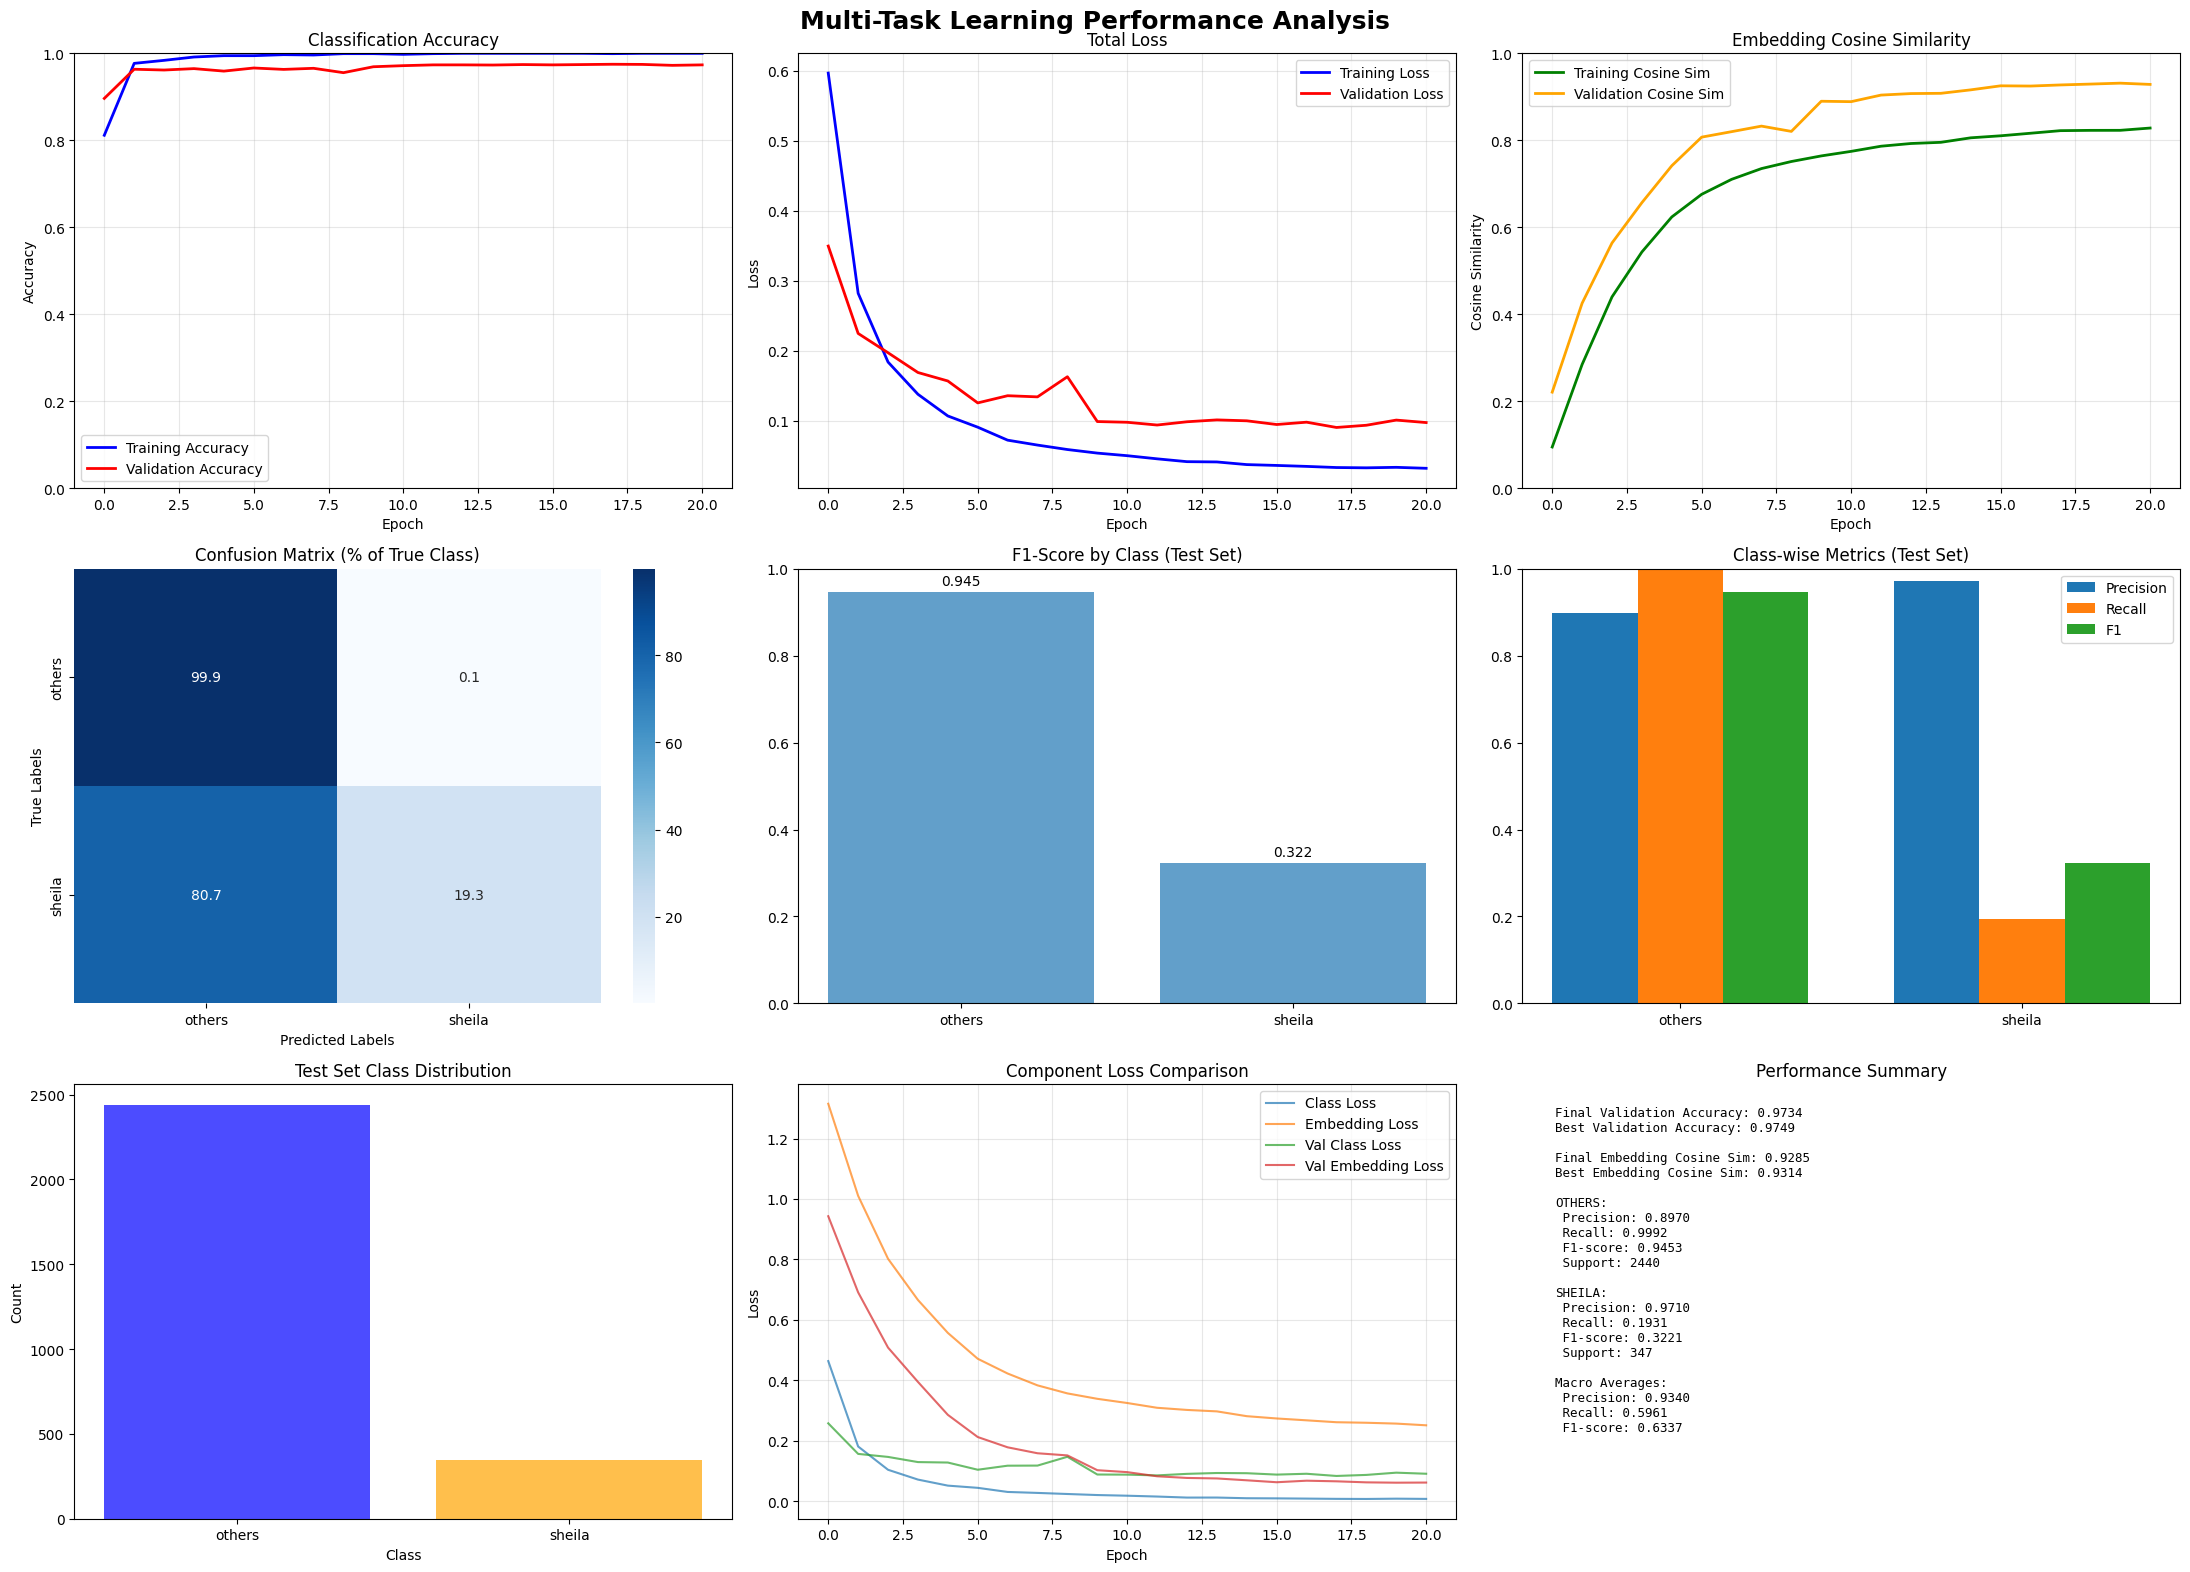

MULTI-TASK LEARNING TRAINING SUMMARY
Total epochs trained: 21
Best validation accuracy: 0.9749
Final validation accuracy: 0.9734
Best embedding cosine similarity: 0.9314
Final embedding cosine similarity: 0.9285

Test Set Performance:
              precision    recall  f1-score   support

      others       0.90      1.00      0.95      2440
      sheila       0.97      0.19      0.32       347

    accuracy                           0.90      2787
   macro avg       0.93      0.60      0.63      2787
weighted avg       0.91      0.90      0.87      2787


Overall Weighted Metrics:
F1-Score: 0.8677
Precision: 0.9062
Recall: 0.8988
Phase 4 completed successfully! ✅


In [41]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import numpy as np
import matplotlib.pyplot as plt

print("=== PHASE 4: Multi-Task Student Training ===")

# --- Convert everything to TensorFlow tensors to avoid compatibility issues ---
X_train_tensor = tf.convert_to_tensor(X_train_flat, dtype=tf.float32)
X_val_tensor = tf.convert_to_tensor(X_val_flat, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test_flat, dtype=tf.float32)

y_train_class_tensor = tf.convert_to_tensor(y_train_categorical, dtype=tf.float32)
y_val_class_tensor = tf.convert_to_tensor(y_val_categorical, dtype=tf.float32)

y_train_embed_tensor = tf.convert_to_tensor(y_embeddings_train, dtype=tf.float32)
y_val_embed_tensor = tf.convert_to_tensor(y_embeddings_val, dtype=tf.float32)

print("Data converted to TensorFlow tensors")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight

class F1Score(tf.keras.metrics.Metric):
    """Streaming multi-class F1 metric for sparse integer labels."""
    
    def __init__(self, num_classes, average="weighted", name="f1_score", **kwargs):
        super().__init__(name=name, **kwargs)
        assert average in ("macro", "weighted")
        self.num_classes = num_classes
        self.average = average

        # Per-class accumulators
        self.tp = self.add_weight(name="tp", shape=(num_classes,), initializer="zeros")
        self.fp = self.add_weight(name="fp", shape=(num_classes,), initializer="zeros")
        self.fn = self.add_weight(name="fn", shape=(num_classes,), initializer="zeros")
        self.support = self.add_weight(name="support", shape=(num_classes,), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert one-hot to sparse if needed
        if len(y_true.shape) > 1:
            y_true = tf.argmax(y_true, axis=1)
        
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred_labels = tf.argmax(y_pred, axis=1, output_type=tf.int32)

        # Confusion matrix
        cm = tf.math.confusion_matrix(y_true, y_pred_labels, num_classes=self.num_classes, dtype=self.dtype)
        
        # Per-class counts
        tp = tf.linalg.diag_part(cm)
        fp = tf.reduce_sum(cm, axis=0) - tp
        fn = tf.reduce_sum(cm, axis=1) - tp
        support = tf.reduce_sum(cm, axis=1)

        self.tp.assign_add(tf.cast(tp, self.dtype))
        self.fp.assign_add(tf.cast(fp, self.dtype))
        self.fn.assign_add(tf.cast(fn, self.dtype))
        self.support.assign_add(tf.cast(support, self.dtype))

    def result(self):
        eps = tf.keras.backend.epsilon()
        precision = self.tp / (self.tp + self.fp + eps)
        recall = self.tp / (self.tp + self.fn + eps)
        f1_per_class = 2.0 * precision * recall / (precision + recall + eps)

        if self.average == "macro":
            return tf.reduce_mean(f1_per_class)
        else:  # "weighted"
            weights = self.support / (tf.reduce_sum(self.support) + eps)
            return tf.reduce_sum(f1_per_class * weights)

    def reset_state(self):
        for v in (self.tp, self.fp, self.fn, self.support):
            v.assign(tf.zeros_like(v))

def plot_multi_task_performance(history, student_model, X_test_flat, y_test, class_names):
    """Create comprehensive graphs for multi-task learning performance analysis"""
    
    # Get predictions from the final deployable model
    y_pred_proba = final_deployable_model.predict(X_test_flat)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    # Convert y_test to categorical if needed
    if len(y_test.shape) > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test
    
    # Calculate metrics for each class
    def calculate_class_metrics(y_true, y_pred, class_names):
        metrics = {}
        for i, class_name in enumerate(class_names):
            # Binary metrics for each class
            precision = precision_score(y_true, y_pred, average=None)[i]
            recall = recall_score(y_true, y_pred, average=None)[i]
            f1 = f1_score(y_true, y_pred, average=None)[i]
            support = np.sum(y_true == i)
            
            metrics[class_name] = {
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'support': support
            }
        return metrics
    
    metrics = calculate_class_metrics(y_true, y_pred, class_names)
    
    # Create figure
    fig, axes = plt.subplots(3, 3, figsize=(22, 16))
    fig.suptitle('Multi-Task Learning Performance Analysis', fontsize=18, fontweight='bold')
    
    # 1. Classification Accuracy
    axes[0, 0].plot(history.history['class_output_accuracy'], label='Training Accuracy', linewidth=2, color='blue')
    axes[0, 0].plot(history.history['val_class_output_accuracy'], label='Validation Accuracy', linewidth=2, color='red')
    axes[0, 0].set_title('Classification Accuracy')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(0, 1)
    
    # 2. Total Loss
    axes[0, 1].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[0, 1].set_title('Total Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Embedding Cosine Similarity
    axes[0, 2].plot(history.history['embedding_output_embedding_cosine_accuracy'], 
                   label='Training Cosine Sim', linewidth=2, color='green')
    axes[0, 2].plot(history.history['val_embedding_output_embedding_cosine_accuracy'], 
                   label='Validation Cosine Sim', linewidth=2, color='orange')
    axes[0, 2].set_title('Embedding Cosine Similarity')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Cosine Similarity')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    axes[0, 2].set_ylim(0, 1)
    
    # 4. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
    axes[1, 0].set_title('Confusion Matrix (% of True Class)')
    axes[1, 0].set_xlabel('Predicted Labels')
    axes[1, 0].set_ylabel('True Labels')
    
    # 5. F1-Score by class
    class_f1_scores = [metrics[c]['f1'] for c in class_names]
    bars = axes[1, 1].bar(range(len(class_names)), class_f1_scores, alpha=0.7)
    axes[1, 1].set_title('F1-Score by Class (Test Set)')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].set_xticks(range(len(class_names)))
    axes[1, 1].set_xticklabels(class_names)
    for bar, value in zip(bars, class_f1_scores):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.3f}', ha='center', va='bottom')
    
    # 6. Precision-Recall-F1 grouped bars
    precision_values = [metrics[c]['precision'] for c in class_names]
    recall_values = [metrics[c]['recall'] for c in class_names]
    f1_values = [metrics[c]['f1'] for c in class_names]
    width = 0.25
    idx = np.arange(len(class_names))
    axes[1, 2].bar(idx - width, precision_values, width, label="Precision")
    axes[1, 2].bar(idx, recall_values, width, label="Recall")
    axes[1, 2].bar(idx + width, f1_values, width, label="F1")
    axes[1, 2].set_title('Class-wise Metrics (Test Set)')
    axes[1, 2].set_xticks(idx)
    axes[1, 2].set_xticklabels(class_names)
    axes[1, 2].legend()
    axes[1, 2].set_ylim(0, 1)
    
    # 7. Sample counts (stacked)
    unique, counts = np.unique(y_true, return_counts=True)
    axes[2, 0].bar(unique, counts, color=['blue', 'orange'], alpha=0.7)
    axes[2, 0].set_title('Test Set Class Distribution')
    axes[2, 0].set_xlabel('Class')
    axes[2, 0].set_ylabel('Count')
    axes[2, 0].set_xticks(unique)
    axes[2, 0].set_xticklabels(class_names)
    
    # 8. Training metrics comparison
    axes[2, 1].plot(history.history['class_output_loss'], label='Class Loss', alpha=0.7)
    axes[2, 1].plot(history.history['embedding_output_loss'], label='Embedding Loss', alpha=0.7)
    axes[2, 1].plot(history.history['val_class_output_loss'], label='Val Class Loss', alpha=0.7)
    axes[2, 1].plot(history.history['val_embedding_output_loss'], label='Val Embedding Loss', alpha=0.7)
    axes[2, 1].set_title('Component Loss Comparison')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Loss')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    
    # 9. Metrics summary text
    metrics_text = f"Final Validation Accuracy: {history.history['val_class_output_accuracy'][-1]:.4f}\n"
    metrics_text += f"Best Validation Accuracy: {max(history.history['val_class_output_accuracy']):.4f}\n\n"
    metrics_text += f"Final Embedding Cosine Sim: {history.history['val_embedding_output_embedding_cosine_accuracy'][-1]:.4f}\n"
    metrics_text += f"Best Embedding Cosine Sim: {max(history.history['val_embedding_output_embedding_cosine_accuracy']):.4f}\n\n"
    
    # Class-wise metrics
    for c in class_names:
        metrics_text += f"{c.upper()}:\n"
        metrics_text += f" Precision: {metrics[c]['precision']:.4f}\n"
        metrics_text += f" Recall: {metrics[c]['recall']:.4f}\n"
        metrics_text += f" F1-score: {metrics[c]['f1']:.4f}\n"
        metrics_text += f" Support: {metrics[c]['support']}\n\n"

    # Macro averages
    macro_precision = np.mean([metrics[c]['precision'] for c in class_names])
    macro_recall = np.mean([metrics[c]['recall'] for c in class_names])
    macro_f1 = np.mean([metrics[c]['f1'] for c in class_names])
    
    metrics_text += f"Macro Averages:\n Precision: {macro_precision:.4f}\n Recall: {macro_recall:.4f}\n F1-score: {macro_f1:.4f}"
    
    axes[2, 2].text(0.05, 0.95, metrics_text, transform=axes[2, 2].transAxes, 
                    fontfamily='monospace', verticalalignment='top', fontsize=9)
    axes[2, 2].set_title('Performance Summary')
    axes[2, 2].set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive report
    print("=" * 70)
    print("MULTI-TASK LEARNING TRAINING SUMMARY")
    print("=" * 70)
    print(f"Total epochs trained: {len(history.history['loss'])}")
    print(f"Best validation accuracy: {max(history.history['val_class_output_accuracy']):.4f}")
    print(f"Final validation accuracy: {history.history['val_class_output_accuracy'][-1]:.4f}")
    print(f"Best embedding cosine similarity: {max(history.history['val_embedding_output_embedding_cosine_accuracy']):.4f}")
    print(f"Final embedding cosine similarity: {history.history['val_embedding_output_embedding_cosine_accuracy'][-1]:.4f}")
    
    print("\nTest Set Performance:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Calculate overall metrics
    overall_f1 = f1_score(y_true, y_pred, average='weighted')
    overall_precision = precision_score(y_true, y_pred, average='weighted')
    overall_recall = recall_score(y_true, y_pred, average='weighted')
    
    print(f"\nOverall Weighted Metrics:")
    print(f"F1-Score: {overall_f1:.4f}")
    print(f"Precision: {overall_precision:.4f}")
    print(f"Recall: {overall_recall:.4f}")
    
    return fig

# Usage example:
# 

# --- Build Multi-Task Student Model ---
def build_multi_task_student(inverter_model, input_dim=1600, embedding_dim=256, num_classes=2):
    """Builds the student model with classification and embedding outputs"""
    #inputs = layers.Input(shape=(input_dim,), name='input')
    
    # Shared hidden layers
    #x = layers.Dense(256, activation='relu', name='dense_1')(inputs)
    #x = layers.Dropout(0.5, name='dropout_1')(x)
    
    #x = layers.Dense(256, activation='relu', name='dense_2')(x)
    #x = layers.Dropout(0.5, name='dropout_2')(x)
    
    #x = layers.Dense(256, activation='relu', name='dense_3')(x)
    #x = layers.Dropout(0.5, name='dropout_3')(x)
    
    # Output 1: Classification
    #class_output = layers.Dense(num_classes, activation='softmax', name='class_output')(x)
    
    # Output 2: Embedding Regression
    #embedding_output = layers.Dense(embedding_dim, activation='linear', name='embedding_output')(x)

    inputs=inverter_model.input
    x=inverter_model.layers[1].output
    for layer in inverter_model.layers[2:-1]:
        x=layer(x)
    #for layer in inverter_model.layers:
    #    layer.trainable=True
    embedding_output=layers.Dense(embedding_dim, activation='linear', name='embedding_output')(x)
    class_output=layers.Dense(num_classes, activation='softmax', name='class_output')(x)
    model = models.Model(
        inputs=inputs, 
        outputs=[class_output, embedding_output],
        name='multi_task_student'
    )
    return model

# --- Custom metric: Cosine Similarity ---
def embedding_cosine_accuracy(y_true, y_pred):
    y_true_normalized = tf.math.l2_normalize(y_true, axis=1)
    y_pred_normalized = tf.math.l2_normalize(y_pred, axis=1)
    cosine_sim = tf.reduce_sum(y_true_normalized * y_pred_normalized, axis=1)
    return tf.reduce_mean(cosine_sim)

# --- Build and compile the student model (SIMPLIFIED - no focal loss for now) ---
student_model = build_multi_task_student(inverter_model, embedding_dim=X_train_features.shape[1])
student_model.summary()

# Use standard loss functions first to ensure stability
student_model.compile(
    optimizer=optimizers.Adam(
        learning_rate=0.0001,  # Low learning rate
        clipnorm=1.0           # Gradient clipping
    ),
    loss={
        'class_output': 'categorical_crossentropy',
        'embedding_output': 'mse'
    },
    loss_weights={
        'class_output': 1.0,      # Main task
        'embedding_output': 0.1  # Low weight for auxiliary task
    },
    metrics={
        'class_output': ['accuracy', F1Score(num_classes=n_classes, average='weighted')],
        'embedding_output': ['mse', embedding_cosine_accuracy]
    }
)

# --- Simple callbacks ---
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_final_model.h5',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
]

# --- Train with TensorFlow tensors ---
print("Starting multi-task training...")
history = student_model.fit(
    x=X_train_tensor,
    y={
        'class_output': y_train_class_tensor,
        'embedding_output': y_train_embed_tensor
    },
    validation_data=(
        X_val_tensor,
        {
            'class_output': y_val_class_tensor,
            'embedding_output': y_val_embed_tensor
        }
    ),
    epochs=100,  # Start with fewer epochs
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# --- Create Final Deployable Model ---
print("Creating final deployable model...")
deployable_input = layers.Input(shape=(1600,), name='input')

# Re-use trained layers
x = student_model.get_layer('dense_1')(deployable_input)
x = student_model.get_layer('bn_1')(x)
x = student_model.get_layer('activation_1')(x)
x = student_model.get_layer('dropout_1')(x)
x = student_model.get_layer('dense_2')(x)
x = student_model.get_layer('bn_2')(x)
x = student_model.get_layer('activation_2')(x)
x = student_model.get_layer('dropout_2')(x)
x = student_model.get_layer('dense_3')(x)
x = student_model.get_layer('bn_3')(x)
x = student_model.get_layer('activation_3')(x)
x = student_model.get_layer('dropout_3')(x)
class_output = student_model.get_layer('class_output')(x)

final_deployable_model = models.Model(
    inputs=deployable_input, 
    outputs=class_output,
    name='final_deployable_student'
)

final_deployable_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

final_deployable_model.summary()

# --- Evaluate ---
print("Evaluating final deployable model...")
y_test_categorical = tf.keras.utils.to_categorical(y_test, num_classes=2)
test_loss, test_accuracy = final_deployable_model.evaluate(
    X_test_flat, 
    y_test_categorical,
    verbose=1
)

print(f"\n=== FINAL RESULTS ===")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# --- Save the final model ---
final_deployable_model.save('final_deployable_student_model.h5')
print("Final model saved as 'final_deployable_student_model.h5'")

# --- Plot training history ---
plot_multi_task_performance(history, final_deployable_model, X_test_flat, y_test, ['others', 'sheila'])

print("Phase 4 completed successfully! ✅")

In [42]:
import numpy as np
import tensorflow as tf

def fuse_dense_and_bn(dense_layer, bn_layer):
    W = dense_layer.get_weights()[0]
    gamma = bn_layer.gamma.numpy()
    beta = bn_layer.beta.numpy()
    moving_mean = bn_layer.moving_mean.numpy()
    moving_var = bn_layer.moving_variance.numpy()
    eps = bn_layer.epsilon
    
    scale = gamma / np.sqrt(moving_var + eps)
    W_new = W * scale[np.newaxis, :]
    b_new = beta - moving_mean * scale
    return W_new, b_new

def get_activation_function(activation_layer):
    if hasattr(activation_layer, 'activation'):
        return activation_layer.activation
    elif hasattr(activation_layer, 'get_config'):
        config=activation_layer.get_config()
        return config.get('activation', 'linear')
    else:
        return 'linear'
    
def fusion_model_creation(model):
    layers=model.layers
    input_layer=tf.keras.Input(shape=model.input_shape[1:], name="input")
    x=input_layer
    i=0
    fused_layers_info=[]
    while i<len(layers):
        layer=layers[i]
        if(isinstance(layer, tf.keras.layers.Dense) and not layer.use_bias and i+2<len(layers)):
            bn_layer=layers[i+1]
            activation_layer=layers[i+2]
            if (isinstance(bn_layer, tf.keras.layers.BatchNormalization) and isinstance(activation_layer, tf.keras.layers.Activation)):
                print(f"Fusion {layer.name} -> {bn_layer.name} -> {activation_layer.name}")
                activation_func=get_activation_function(activation_layer)
                W_new, b_new=fuse_dense_and_bn(layer, bn_layer)
                new_dense_layer=tf.keras.layers.Dense(
                    units=layer.units,
                    use_bias=True,
                    activation=activation_func,
                    name=layer.name+"_fusion"
                )
                x=new_dense_layer(x)
                fused_layers_info.append((new_dense_layer, W_new, b_new))
            if i+3<len(layers) and isinstance(layers[i+3], tf.keras.layers.Dropout):
                dropout_layer=layers[i+3]
                dropout=tf.keras.layers.Dropout(
                    rate=dropout_layer.rate,
                    name=dropout_layer.name
                )
                x=dropout(x)
                i+=4
            else:
                i+=3
            continue
        elif isinstance(layer, tf.keras.layers.Dense):
            print(f"Adding Dense layer: {layer.name}")
        
            dense_layer=tf.keras.layers.Dense(
                units=layer.units,
                use_bias=layer.use_bias,
                activation=layer.activation,
                name=layer.name
            )
            x=dense_layer(x)
            if layer.get_weights():
                fused_layers_info.append((dense_layer, *layer.get_weights()))
            i+=1
        elif isinstance(layer, tf.keras.layers.Dropout):
            print(f"Adding Dropout layer: {layer.name}")
            dropout=tf.keras.layers.Dropout(
                rate=layer.rate,
                name=layer.name
            )
            x=dropout(x)
            i+=1
        elif isinstance(layer, tf.keras.layers.BatchNormalization):
            print(f"Adding Standalone BatchNormalization")
            bn=tf.keras.layers.BatchNormalization(
                epsilon=layer.epsilon,
                momentum=layer.momentum,
                name=layer.name
            )
            x=bn(x)
            if layer.get_weights():
                fused_layers_info.append((bn, *layer.get_weights()))
            i+=1
        else:
            print(f"Adding layer: {layer.name}")
            try:
                new_layer=layer.__class__.from_config(layer.get_config())
                x=new_layer(x)
                if hasattr(layer, 'get_weights') and layer.get_weights():
                    fused_layers_info.append((new_layer, *layer.get_weights()))
            except Exception as e:
                print(f"Warinng: Could not copy layer {layer.name}: {e}")
            i+=1
    new_model=tf.keras.Model(
        inputs=input_layer,
        outputs=x,
        name=model.name+"_fusion"
    )
    dummy_input=tf.zeros((1, *model.input_shape[1:]))
    _=model(dummy_input)
    
    for layer_info in fused_layers_info:
        layer_obj=layer_info[0]
        weights=layer_info[1:]
        try:
            layer_obj.set_weights(list(weights))
        except Exception as e:
            print(f"Warning: Could not set weights for {layer_obj.name}")
    return new_model
    
def compare_models(original_model, fused_model, test_data, tolerance=1e-6):
    """Compare outputs of original and fused models"""
    
    # Get predictions
    y1 = original_model(test_data, training=False).numpy()
    y2 = fused_model(test_data, training=False).numpy()
    
    # Calculate metrics
    mse = np.mean((y1 - y2) ** 2)
    max_diff = np.max(np.abs(y1 - y2))
    mean_diff = np.mean(np.abs(y1 - y2))
    
    if np.mean(y1 ** 2) > 0:
        closeness = 100 * (1 - mse / np.mean(y1 ** 2))
    else:
        closeness = 100.0 if mse == 0 else 0.0
    
    print(f"\nModel comparison:")
    print(f"MSE: {mse:.8f}")
    print(f"Max difference: {max_diff:.8f}")
    print(f"Mean absolute difference: {mean_diff:.8f}")
    print(f"Closeness: {closeness:.6f}%")
    
    # Sample comparison
    print(f"\nSample comparison:")
    print(f"Original[0]: {y1[0]}")
    print(f"Fused[0]:    {y2[0]}")
    print(f"Difference:  {np.abs(y1[0] - y2[0])}")
    
    # Determine success
    if max_diff < tolerance:
        print("✓ Fusion successful! Models are mathematically equivalent.")
        return True
    elif max_diff < 1e-3:
        print("⚠ Models are very close. Small differences may be due to numerical precision.")
        return True
    else:
        print("❌ Fusion failed. Models are significantly different.")
        return False

def main():
    try:
        print("Creating Model Fusion")
        new_model=fusion_model_creation(final_deployable_model)
        new_model.summary()
        success=compare_models(final_deployable_model, new_model, X_test_flat, 1e-3)
        if success:
            print("\nModel fusion completed successfully")
            new_model.save("final_model.h5")
            print("Final Model is ready for deployment on Syntiant ✅")
        else:
            print("\nModel Fusion failed!")
    except Exception as e:
        print(f"Error during model fusion: {e}")
        import traceback
        traceback.print_exc()
        return None
if __name__=="__main__":
    final_model=main()

Creating Model Fusion
Adding layer: input
Warinng: Could not copy layer input: too many positional arguments
Fusion dense_1 -> bn_1 -> activation_1
Fusion dense_2 -> bn_2 -> activation_2
Fusion dense_3 -> bn_3 -> activation_3
Adding Dense layer: class_output


Model: "final_deployable_student_fusion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1_fusion (Dense)          │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2_fusion (Dense)          │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3_fusion (Dense)          │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_output (Dense)            │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,954 (2.07 MB)

 Trainable params: 541,954 (2.07 MB)

 Non-trainable params: 0 (0.00 B)


Model comparison:
MSE: 0.00000000
Max difference: 0.00000048
Mean absolute difference: 0.00000006
Closeness: 100.000000%

Sample comparison:
Original[0]: [0.9423077  0.05769224]
Fused[0]:    [0.94230783 0.05769222]
Difference:  [1.1920929e-07 2.2351742e-08]
✓ Fusion successful! Models are mathematically equivalent.

Model fusion completed successfully
Final Model is ready for deployment on Syntiant ✅
